In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from utils.animal_dataset import AnimalDataset
from model import ModelCnn
from utils.early_stopping import EarlyStopping
from utils.testing import Testing
from utils.training import Trainer

/home/mamp/Documents/semestre8/redes-neuronales-vision-computacion/proyecto/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Transformations for the dataset
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Transformaciones fijas para validación y prueba
val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.64].


Total de imágenes cargadas: 1052
Formato del tensor: torch.Size([3, 224, 224])
Clase detectada: 3


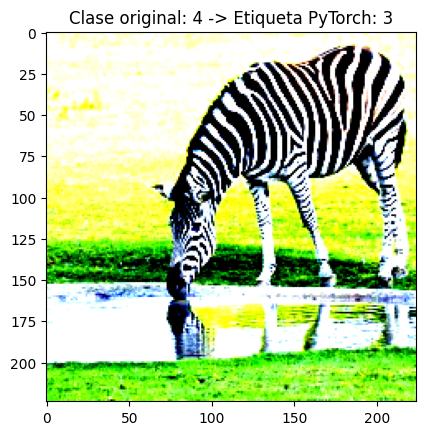

In [3]:
# Loading data

train_data = AnimalDataset(root_dir="../../data/africa-wildlife/images/train", transform=train_transform)

print(f"Total de imágenes cargadas: {len(train_data)}")

# Take a sample
img, label = train_data[0]
print(f"Formato del tensor: {img.shape}") # Should be [3, 224, 224]
print(f"Clase detectada: {label}")

plt.imshow(img.permute(1, 2, 0))
plt.title(f"Clase original: {label + 1} -> Etiqueta PyTorch: {label}")
plt.show()

In [4]:
val_data = AnimalDataset(root_dir="../../data/africa-wildlife/images/val", transform=val_test_transforms)
test_data = AnimalDataset(root_dir="../../data/africa-wildlife/images/test", transform=val_test_transforms)


In [5]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False, num_workers=2)

In [6]:
# Model Hyperparameters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

model = ModelCnn(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

Usando: cuda


In [7]:
# Training model

model_trainer = Trainer(model, device, criterion, optimizer, EarlyStopping(patience=5))
history = model_trainer.fit(train_loader, val_loader, 20)

Epoch 1/20 -> Train Loss: 1.3610 | Acc: 39.54% | Val Loss: 1.0818 | Val Acc: 51.56%


Epoch 2/20 -> Train Loss: 0.9763 | Acc: 55.23% | Val Loss: 1.0259 | Val Acc: 45.78%


Epoch 3/20 -> Train Loss: 0.9059 | Acc: 59.98% | Val Loss: 1.1114 | Val Acc: 53.33%


Epoch 4/20 -> Train Loss: 0.8308 | Acc: 65.68% | Val Loss: 0.9927 | Val Acc: 60.44%


Epoch 5/20 -> Train Loss: 0.7852 | Acc: 65.11% | Val Loss: 0.9989 | Val Acc: 61.33%


...

Epoch 9/20 -> Train Loss: 0.5508 | Acc: 78.14% | Val Loss: 1.0469 | Val Acc: 64.00%


Epoch 10/20 -> Train Loss: 0.4979 | Acc: 79.66% | Val Loss: 0.9997 | Val Acc: 62.67%


Epoch 11/20 -> Train Loss: 0.4845 | Acc: 81.37% | Val Loss: 1.1472 | Val Acc: 68.89%


Epoch 12/20 -> Train Loss: 0.4151 | Acc: 83.65% | Val Loss: 1.1566 | Val Acc: 65.33%


Epoch 13/20 -> Train Loss: 0.4086 | Acc: 84.89% | Val Loss: 1.0644 | Val Acc: 68.00%
Early stopping activado. Terminando...


In [7]:
# Testing model

model_tester = Testing(model, "best_model.pth", device, criterion)
test_loss = model_tester.test(test_loader)

tensor([1, 0, 2, 1, 3, 1, 3, 0, 2, 0, 2, 3, 1, 2, 1, 2, 0, 1, 2, 1, 0, 0, 3, 1,
        3, 2, 0, 2, 0, 3, 3, 2], device='cuda:0')
tensor([2, 3, 2, 2, 1, 0, 0, 2, 3, 0, 3, 2, 0, 3, 1, 0, 2, 1, 3, 1, 3, 3, 3, 3,
        1, 2, 0, 3, 0, 0, 2, 2], device='cuda:0')
tensor([2, 3, 3, 1, 3, 1, 0, 0, 1, 3, 0, 3, 3, 2, 2, 3, 1, 3, 3, 0, 1, 0, 1, 3,
        0, 0, 0, 3, 2, 2, 2, 0], device='cuda:0')
tensor([2, 1, 0, 0, 1, 2, 3, 2, 1, 3, 0, 0, 2, 2, 0, 2, 0, 3, 3, 0, 2, 2, 3, 0,
        3, 2, 1, 2, 1, 3, 2, 2], device='cuda:0')
tensor([3, 0, 1, 2, 3, 2, 1, 1, 3, 3, 0, 1, 1, 1, 1, 3, 1, 3, 0, 1, 0, 1, 2, 2,
        3, 2, 3, 3, 1, 2, 2, 1], device='cuda:0')
tensor([1, 2, 1, 1, 2, 1, 3, 2, 3, 2, 1, 3, 0, 0, 3, 3, 3, 3, 1, 0, 1, 3, 3, 3,
        1, 2, 2, 0, 2, 2, 2, 3], device='cuda:0')
tensor([1, 2, 0, 1, 3, 0, 1, 0, 2, 1, 1, 0, 2, 1, 0, 0, 1, 3, 3, 2, 1, 0, 2, 3,
        1, 1, 3, 0, 1, 3, 0, 0], device='cuda:0')
tensor([1, 1, 2], device='cuda:0')
Test Accuracy Global: 74.8898678414097%
Accuracy de buf